In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [2]:
df_original = pd.read_csv("data/NSE-TATAGLOBAL.csv")
df = df_original
df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-09-28,234.05,235.95,230.20,233.50,233.75,3069914,7162.35
1,2018-09-27,234.55,236.80,231.10,233.80,233.25,5082859,11859.95
2,2018-09-26,240.00,240.00,232.50,235.00,234.25,2240909,5248.60
3,2018-09-25,233.30,236.75,232.00,236.25,236.10,2349368,5503.90
4,2018-09-24,233.55,239.20,230.75,234.00,233.30,3423509,7999.55


In [3]:
df.Date = pd.to_datetime(df['Date'])

In [4]:
df = df.sort_values('Date').reset_index(drop=True)

# ADDING FEATURES

In [5]:
# Base Returns & Lagged Signals
df["Daily_Return"] = (
    100 * (df["Close"] - df["Close"].shift(1)) / df["Close"].shift(1)
)
df["Intraday_Return"] = (df["Close"] - df["Open"]) / df["Open"]
df["Daily_Range"] = (df["High"] - df["Low"]) / df["Low"]

df["Return_Lag1"] = df["Daily_Return"].shift(1)
df["Return_Lag2"] = df["Daily_Return"].shift(2)
df["Return_Lag3"] = df["Daily_Return"].shift(3)
df["Return_Lag4"] = df["Daily_Return"].shift(4)
df["Return_Lag5"] = df["Daily_Return"].shift(5)

# Multi-Horizon Momentum & RSI
df["Return_5D"] = (
    100 * (df["Close"] - df["Close"].shift(5)) / df["Close"].shift(5)
)
df["Return_10D"] = (
    100 * (df["Close"] - df["Close"].shift(10)) / df["Close"].shift(10)
)

delta = df["Close"].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df["RSI_14"] = 100 - (100 / (1 + (gain / (loss + 1e-9))))

# Moving Average Ratios (Trend Alignment)
df["Close_to_MA10"] = df["Close"] / df["Close"].rolling(10).mean()
df["Close_to_MA50"] = df["Close"] / df["Close"].rolling(50).mean()
df["MA10_to_MA50"] = (
    df["Close"].rolling(10).mean() / df["Close"].rolling(50).mean()
)

# Volatility & Regime Shifts
df["Volatility10"] = df["Daily_Return"].rolling(10).std()
df["Volatility30"] = df["Daily_Return"].rolling(30).std()
df["Vol_Ratio_10_30"] = df["Volatility10"] / (df["Volatility30"] + 1e-9)

# Volume & VWAP Ratios
df["Turnover_to_MA10"] = df["Turnover (Lacs)"] / df[
    "Turnover (Lacs)"
].rolling(10).mean()
df["Volume_to_MA10"] = df["Total Trade Quantity"] / df[
    "Total Trade Quantity"
].rolling(10).mean()
df["Volume_Lag1"] = df["Total Trade Quantity"] / df[
    "Total Trade Quantity"
].shift(1)

# Raw VWAP calculation (keep VWAP out of X_train, use only Close_to_VWAP)
df["VWAP"] = (df["Turnover (Lacs)"] * 100000) / df["Total Trade Quantity"]
df["Close_to_VWAP"] = df["Close"] / df["VWAP"]

# Candlestick Anatomy
hl_span = (df["High"] - df["Low"]) + 1e-9
df["Close_Location"] = (df["Close"] - df["Low"]) / hl_span
df["Upper_Shadow_Ratio"] = (
    df["High"] - df[["Open", "Close"]].max(axis=1)
) / hl_span
df["Lower_Shadow_Ratio"] = (
    df[["Open", "Close"]].min(axis=1) - df["Low"]
) / hl_span

# Target Setup
df["Target_Return"] = df["Daily_Return"].shift(-1)
df["Target_Class"] = (df["Target_Return"] > 0).astype(int)

# #rule : no absolute values so model doesnt cheat

In [6]:
df.dropna(inplace=True)
df.reset_index(inplace=True,drop=True)

In [7]:
df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs),Daily_Return,Intraday_Return,...,Turnover_to_MA10,Volume_to_MA10,Volume_Lag1,VWAP,Close_to_VWAP,Close_Location,Upper_Shadow_Ratio,Lower_Shadow_Ratio,Target_Return,Target_Class
0,2010-09-29,123.3,124.75,121.20,121.25,121.50,984606,1206.81,-1.098901,-0.014599,...,0.712160,0.718504,1.231683,122.567809,0.991288,0.084507,0.408451,0.084507,-1.069959,0
1,2010-09-30,122.3,122.70,119.15,121.05,120.20,1240038,1495.40,-1.069959,-0.017171,...,0.873384,0.894017,1.259426,120.593079,0.996740,0.295775,0.112676,0.295775,2.745424,1
2,2010-10-01,121.3,124.00,121.30,123.60,123.50,711861,875.04,2.745424,0.018137,...,0.567701,0.570239,0.574064,122.922874,1.004695,0.814815,0.185185,0.000000,0.931174,1
3,2010-10-04,124.4,125.45,123.20,124.20,124.65,670447,833.60,0.931174,0.002010,...,0.558739,0.554970,0.941823,124.334959,1.002534,0.644444,0.355556,0.533333,1.885279,1
4,2010-10-05,125.0,127.90,123.20,127.50,127.00,1542220,1955.79,1.885279,0.016000,...,1.262922,1.234302,2.300286,126.816537,1.001447,0.808511,0.191489,0.382979,1.811024,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  1985 non-null   datetime64[us]
 1   Open                  1985 non-null   float64       
 2   High                  1985 non-null   float64       
 3   Low                   1985 non-null   float64       
 4   Last                  1985 non-null   float64       
 5   Close                 1985 non-null   float64       
 6   Total Trade Quantity  1985 non-null   int64         
 7   Turnover (Lacs)       1985 non-null   float64       
 8   Daily_Return          1985 non-null   float64       
 9   Intraday_Return       1985 non-null   float64       
 10  Daily_Range           1985 non-null   float64       
 11  Return_Lag1           1985 non-null   float64       
 12  Return_Lag2           1985 non-null   float64       
 13  Return_Lag3           1985 no

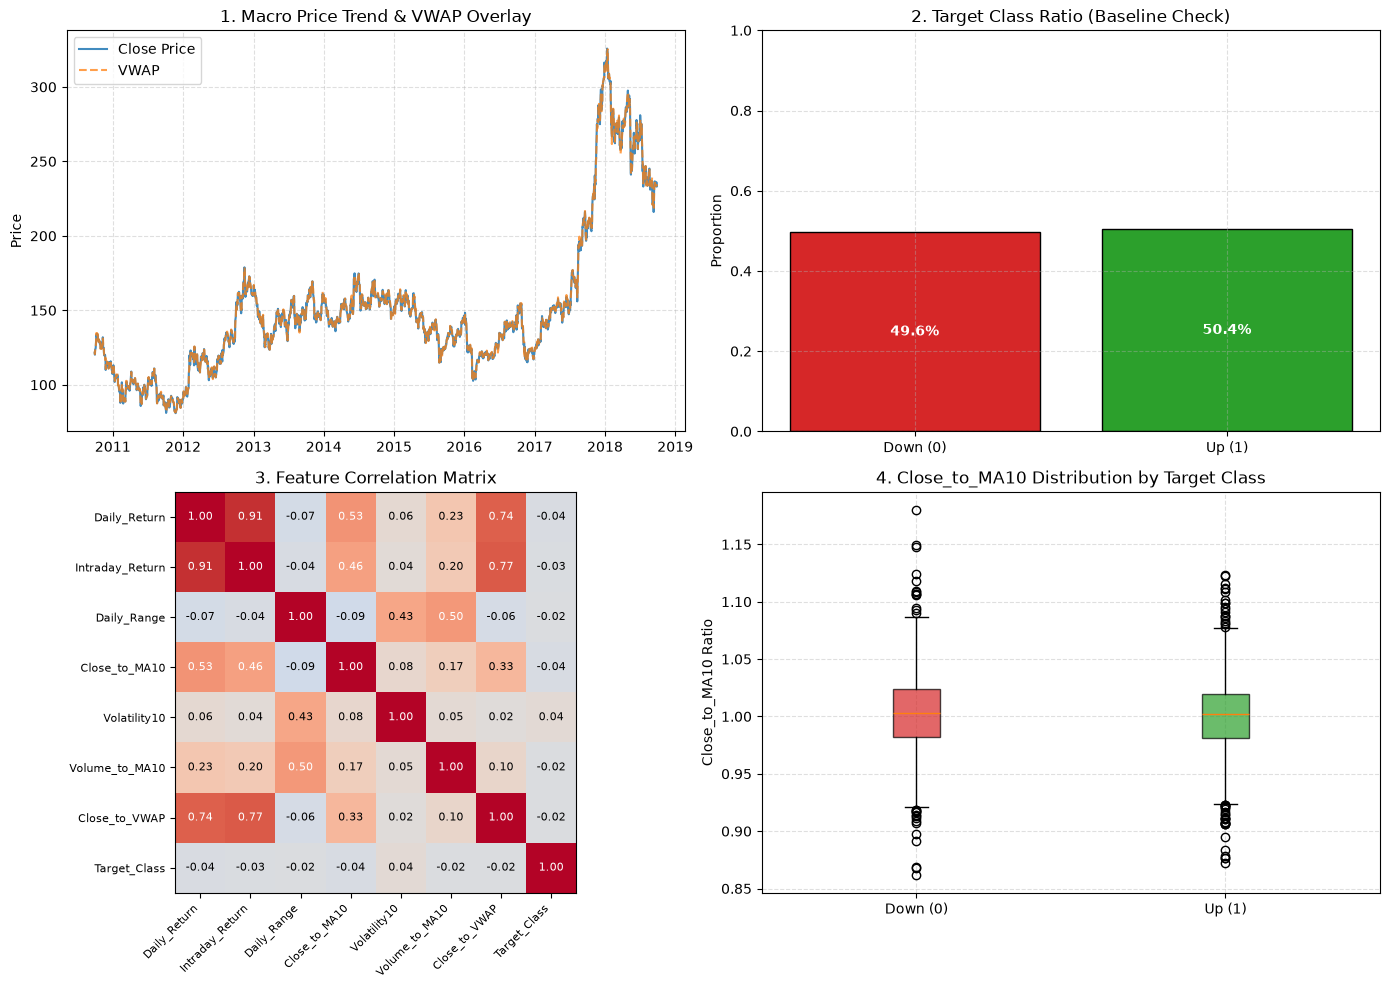

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Macro Price Trend & VWAP Overlay
axes[0, 0].plot(
    df["Date"], df["Close"], label="Close Price", color="tab:blue", alpha=0.85
)
axes[0, 0].plot(
    df["Date"],
    df["VWAP"],
    label="VWAP",
    color="tab:orange",
    linestyle="--",
    alpha=0.75,
)
axes[0, 0].set_title("1. Macro Price Trend & VWAP Overlay")
axes[0, 0].set_ylabel("Price")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.4)

# 2. Target Class Ratio (Baseline Check)
class_counts = df["Target_Class"].value_counts(normalize=True)
bars = axes[0, 1].bar(
    ["Down (0)", "Up (1)"],
    [class_counts.get(0, 0), class_counts.get(1, 0)],
    color=["tab:red", "tab:green"],
    edgecolor="black",
)
axes[0, 1].set_title("2. Target Class Ratio (Baseline Check)")
axes[0, 1].set_ylabel("Proportion")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, linestyle="--", alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2.0,
        yval / 2,
        f"{yval:.1%}",
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )

# 3. Feature Correlation Heatmap (Pure Matplotlib)
key_cols = [
    "Daily_Return",
    "Intraday_Return",
    "Daily_Range",
    "Close_to_MA10",
    "Volatility10",
    "Volume_to_MA10",
    "Close_to_VWAP",
    "Target_Class",
]
corr = df[key_cols].corr().values
im = axes[1, 0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

axes[1, 0].set_xticks(range(len(key_cols)))
axes[1, 0].set_yticks(range(len(key_cols)))
axes[1, 0].set_xticklabels(key_cols, rotation=45, ha="right", fontsize=8)
axes[1, 0].set_yticklabels(key_cols, fontsize=8)
axes[1, 0].set_title("3. Feature Correlation Matrix")

# Annotate correlation values inside heat cells
for i in range(len(key_cols)):
    for j in range(len(key_cols)):
        val = corr[i, j]
        text_color = "white" if abs(val) > 0.45 else "black"
        axes[1, 0].text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
        )

# 4. Feature Separation (Boxplot of Close_to_MA10 by Class)
down_vals = df[df["Target_Class"] == 0]["Close_to_MA10"].dropna()
up_vals = df[df["Target_Class"] == 1]["Close_to_MA10"].dropna()

bp = axes[1, 1].boxplot(
    [down_vals, up_vals],
    patch_artist=True,
    tick_labels=["Down (0)", "Up (1)"],
)
colors = ["tab:red", "tab:green"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_title("4. Close_to_MA10 Distribution by Target Class")
axes[1, 1].set_ylabel("Close_to_MA10 Ratio")
axes[1, 1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [10]:
# Our model should definitely hit score more than 50.2

## splitting into x and y 

In [11]:
X = df.drop(columns=[
    'Target_Class', 'Target_Return',
    'Date', 'Open', 'High', 'Low', 'Last', 'Close',
    'Total Trade Quantity', 'Turnover (Lacs)','VWAP'
])
y = df["Target_Class"]

In [12]:
## feature scaling from sklearn documentation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.12,shuffle=False
)
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_valid = scaler.transform(X_valid)

## TRYING DIFF MODELS

In [13]:
#linear svc
from sklearn import svm
clf_svm = svm.LinearSVC()
clf_svm.fit(scaled_X_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [14]:
clf_svm.score(scaled_X_train,y_train)

0.570446735395189

In [15]:
clf_svm.score(scaled_X_valid,y_valid)

0.4602510460251046

In [16]:
def check_feat(model, x_f):
    # 1. Flatten coef_ to 1D using .ravel()
    importance_df = pd.DataFrame(
        {"Feature": x_f.columns, "Importance": model.coef_.ravel()}
    )

    # 2. Sort by absolute impact (ascending=True puts largest values at top of barh)
    importance_df["Abs_Importance"] = importance_df["Importance"].abs()
    importance_df = importance_df.sort_values(
        by="Abs_Importance", ascending=True
    )

    colors = [
        "tab:green" if val > 0 else "tab:red"
        for val in importance_df["Importance"]
    ]

    # 3. Plot horizontal bar chart
    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"],
        color=colors,
        edgecolor="black",
    )

    # 4. Visual anchors
    plt.axvline(x=0, color="black", linestyle="-", linewidth=1)
    plt.title("Feature Importance (LinearSVC Coefficients)")
    plt.xlabel("Coefficient Weight (Direction & Impact)")
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

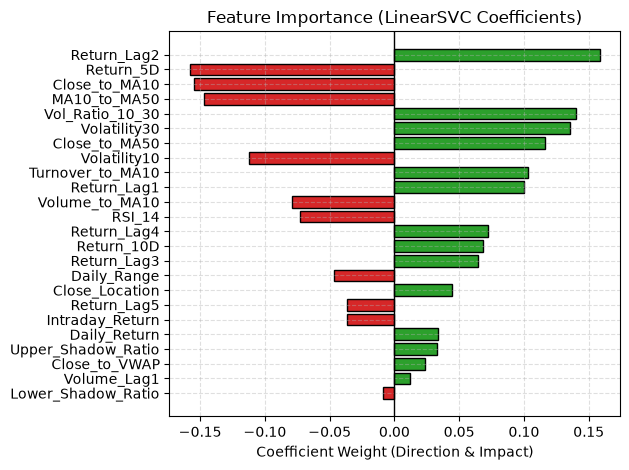

In [17]:
check_feat(clf_svm,scaled_X_valid)

In [18]:
from sklearn.metrics import accuracy_score, f1_score, precision_score

def show_scores(model):
    train_preds = model.predict(scaled_X_train)
    val_preds = model.predict(scaled_X_valid)
    scores = {
        "Training Accuracy": accuracy_score(y_train, train_preds),
        "Valid Accuracy": accuracy_score(y_valid, val_preds),
        "Training Precision": precision_score(y_train, train_preds),
        "Valid Precision": precision_score(y_valid, val_preds),
        "Training F1": f1_score(y_train, train_preds),
        "Valid F1": f1_score(y_valid, val_preds),
    }
    return scores

In [19]:
show_scores(clf_svm)

{'Training Accuracy': 0.570446735395189,
 'Valid Accuracy': 0.4602510460251046,
 'Training Precision': 0.5760743321718932,
 'Valid Precision': 0.463768115942029,
 'Training F1': 0.5694603903559128,
 'Valid F1': 0.4980544747081712}

In [20]:
#knn
from sklearn.neighbors import KNeighborsClassifier
clf_knn = KNeighborsClassifier(n_neighbors=16)
clf_knn.fit(scaled_X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",16
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [21]:
clf_knn.score(scaled_X_valid,y_valid)

0.5104602510460251

In [22]:
show_scores(clf_knn)

{'Training Accuracy': 0.6065292096219931,
 'Valid Accuracy': 0.5104602510460251,
 'Training Precision': 0.6409883720930233,
 'Valid Precision': 0.5102040816326531,
 'Training F1': 0.5621414913957935,
 'Valid F1': 0.4608294930875576}

In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
clf_hgb = HistGradientBoostingClassifier(max_iter=100,random_state=42)
clf_hgb.fit(scaled_X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [24]:
show_scores(clf_hgb)

{'Training Accuracy': 1.0,
 'Valid Accuracy': 0.4895397489539749,
 'Training Precision': 1.0,
 'Valid Precision': 0.488,
 'Training F1': 1.0,
 'Valid F1': 0.5}

In [25]:
from sklearn.ensemble import RandomForestClassifier
clf_rfc = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=30, random_state=42)
clf_rfc.fit(scaled_X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [26]:
show_scores(clf_rfc)

{'Training Accuracy': 0.6225658648339061,
 'Valid Accuracy': 0.4811715481171548,
 'Training Precision': 0.6168421052631579,
 'Valid Precision': 0.48299319727891155,
 'Training F1': 0.6400873839432004,
 'Valid F1': 0.5338345864661654}

In [27]:
from sklearn.linear_model import LogisticRegression

clf_log = LogisticRegression(C=0.1, random_state=42)
clf_log.fit(scaled_X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [28]:
show_scores(clf_log)

{'Training Accuracy': 0.5664375715922108,
 'Valid Accuracy': 0.4476987447698745,
 'Training Precision': 0.5719257540603249,
 'Valid Precision': 0.45255474452554745,
 'Training F1': 0.5656913367756741,
 'Valid F1': 0.484375}

# 📊 Binary Market Classifier Diagnostics (~50% Baseline Target)

### 🎯 Ideal Target Metric Benchmark
* **Accuracy:**   52.0% – 55.0%  (Sustained statistical edge above 50.2% baseline)
* **Precision:**  52.0% – 55.0%  (Proportion of predicted positive trades that actually win)
* **Recall:**     50.0% – 60.0%  (Captures over half of all actual upward moves)
* **F1-Score:**   51.0% – 55.0%  (True harmonic balance between precision and market participation)
  

---

### 🔍 Performance Matrix & Troubleshooting Guide

| Profile | Valid Acc | Valid Prec | Valid Recall | Valid F1 | Diagnosis | Corrective Action |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Goldilocks (Ideal)** | **52–55%** | **52–55%** | **50–60%** | **51–55%** | **Optimal Trade Edge:** Real non-overfitted signal with active market participation. | Proceed to strategy backtesting with slippage/fees. |
| **Paranoid (Risk-Averse)** | 51–53% | >60% | <30% | <40% | **High Precision, Tiny Recall:** Model sits in cash ~80% of the time, missing winning moves. | Lower decision threshold (`val_probs > 0.48`) or ease regularization penalty. |
| **FOMO Spammer** | ~50% | ~50% | >90% | ~65% | **The Recall Trap:** Predicts "Up" constantly. High F1 is a metric math illusion. | Raise decision threshold (`val_probs > 0.52`) or balance class weights. |
| **Noise Memorizer** | <48% | 99% (Train) | 99% (Train) | <45% | **Catastrophic Overfitting:** Decision tree memorized training noise down to leaves. | Set hard constraints: `max_depth=2-3`, `min_samples_leaf=50`. |
| **Inverted Signal** | <48% | <48% | Any | <45% | **Distribution Drift:** Training features send inverted signals in validation set. | Convert absolute values/ratios into rolling Z-scores. |

In [29]:
from sklearn.linear_model import RidgeClassifier

clf_ridge = RidgeClassifier(alpha=10.0, random_state=42)
clf_ridge.fit(scaled_X_train, y_train)

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.For an illustration of the effect of alpha on the model coefficients, see:ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.",10.0
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classe

In [30]:
show_scores(clf_ridge)

{'Training Accuracy': 0.5698739977090492,
 'Valid Accuracy': 0.45188284518828453,
 'Training Precision': 0.5755813953488372,
 'Valid Precision': 0.45588235294117646,
 'Training F1': 0.5686387133831131,
 'Valid F1': 0.48627450980392156}

In [31]:
from sklearn.linear_model import LogisticRegression

clf_lasso = LogisticRegression(
    penalty="l1", solver="liblinear", C=0.05, random_state=42
)
clf_lasso.fit(scaled_X_train, y_train)

C:\Users\SHAURYA\AIML\stock-price-predictor\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\SHAURYA\AIML\stock-price-predictor\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.05
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_

In [32]:
show_scores(clf_lasso)

{'Training Accuracy': 0.5486827033218786,
 'Valid Accuracy': 0.4435146443514644,
 'Training Precision': 0.5590851334180432,
 'Valid Precision': 0.4444444444444444,
 'Training F1': 0.5275779376498801,
 'Valid F1': 0.45714285714285713}

In [33]:
!pip install xgboost

In [34]:
from xgboost import XGBClassifier

clf_xgb = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.02,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42
)
clf_xgb.fit(scaled_X_train, y_train)
show_scores(clf_xgb)

{'Training Accuracy': 0.6036655211912944,
 'Valid Accuracy': 0.4895397489539749,
 'Training Precision': 0.5916585838991271,
 'Valid Precision': 0.48936170212765956,
 'Training F1': 0.6380753138075314,
 'Valid F1': 0.5307692307692308}

## models going into hyperparam tuning: clf_knn, clf_log, clf_ridge

In [35]:
#KNN algo
show_scores(clf_knn)

{'Training Accuracy': 0.6065292096219931,
 'Valid Accuracy': 0.5104602510460251,
 'Training Precision': 0.6409883720930233,
 'Valid Precision': 0.5102040816326531,
 'Training F1': 0.5621414913957935,
 'Valid F1': 0.4608294930875576}

In [36]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings("ignore") 

# 1. Temporal Cross-Validation to avoid lookahead bias
tscv = TimeSeriesSplit(n_splits=5)
# 2. Parameter Grid for KNN
knn_param_grid = {
    # Single-step integer resolution from K=1 to K=60
    "n_neighbors": list(range(1, 61)),
    # Power parameter for Minkowski (1 = Manhattan, 2 = Euclidean, custom fractional metrics)
    "p": [1, 1.25, 1.5, 1.75, 2, 3],
    # Kept strictly 'uniform' to prevent 0-distance memorization
    "weights": ["uniform"],
    # Primary distance metrics
    "metric": ["minkowski", "chebyshev"],
}

# 3. Grid Search Setup
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=tscv,
    scoring="f1",
    n_jobs=-1,
)

# 4. Execute Fit
grid_knn.fit(scaled_X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['minkowski', 'chebyshev'], 'n_neighbors': [1, 2, ...], 'p': [1, 1.25, ...], 'weights': ['uniform']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [37]:
grid_knn.best_params_

{'metric': 'minkowski', 'n_neighbors': 3, 'p': 3, 'weights': 'uniform'}

In [38]:
best_knn = grid_knn.best_estimator_
show_scores(best_knn)

{'Training Accuracy': 0.7416953035509737,
 'Valid Accuracy': 0.5188284518828452,
 'Training Precision': 0.7415730337078652,
 'Valid Precision': 0.515625,
 'Training F1': 0.7453416149068323,
 'Valid F1': 0.5344129554655871}

In [39]:
from joblib import dump,load
dump(best_knn, filename="clf_knn.joblib")
dump(scaler, "feature_scaler.joblib")

['feature_scaler.joblib']

In [40]:
#logistic regression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore") 


# 1. Temporal Cross-Validation to avoid lookahead bias
tscv = TimeSeriesSplit(n_splits=5)
# 2. Parameter Grid for KNN
log_param_grid = {
    "C": np.logspace(-4, 3, 20).tolist(),
    "l1_ratio": np.linspace(0, 1, 11).tolist(),
    "fit_intercept": [True, False],
    "class_weight": [None, "balanced"],
}
# 3. Grid Search Setup
grid_log = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=log_param_grid,
    cv=tscv,
    scoring="f1",
    n_jobs=-1,
)
# 4. Execute Fit
grid_log.fit(scaled_X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.0001, 0.00023357214690901214, ...], 'class_weight': [None, 'balanced'], 'fit_intercept': [True, False], 'l1_ratio': [0.0, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 

In [41]:
grid_log.best_params_

{'C': 33.59818286283781,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'l1_ratio': 0.0}

In [42]:
best_log = grid_log.best_estimator_
show_scores(best_log)

{'Training Accuracy': 0.5675830469644902,
 'Valid Accuracy': 0.46443514644351463,
 'Training Precision': 0.5764563106796117,
 'Valid Precision': 0.4666666666666667,
 'Training F1': 0.5571847507331378,
 'Valid F1': 0.49606299212598426}

In [43]:
from joblib import dump,load
dump(best_log, filename="clf_log.joblib")

['clf_log.joblib']

In [44]:
#ridge classifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import RidgeClassifier

warnings.filterwarnings("ignore") 

# 1. Temporal Cross-Validation to avoid lookahead bias
tscv = TimeSeriesSplit(n_splits=5)
# 2. Parameter Grid for KNN
ridge_param_grid = {
    # Regularization strength (higher = heavier L2 penalty)
    "alpha": np.logspace(-3, 5, 30).tolist(),
    "fit_intercept": [True, False],
    "class_weight": [None, "balanced"],
    "solver": ["auto", "svd", "cholesky", "lsqr", "saga"],
}
# 3. Grid Search Setup
grid_ridge = GridSearchCV(
    estimator=RidgeClassifier(random_state=42),
    param_grid=ridge_param_grid,
    cv=tscv,
    scoring="f1",
    n_jobs=-1,
)
# 4. Execute Fit
grid_ridge.fit(scaled_X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RidgeClassifi...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.0018873918221350976, ...], 'class_weight': [None, 'balanced'], 'fit_intercept': [True, False], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchang

In [45]:
grid_ridge.best_params_

{'alpha': 0.001,
 'class_weight': None,
 'fit_intercept': False,
 'solver': 'saga'}

In [46]:
best_ridge = grid_ridge.best_estimator_
show_scores(best_ridge)

{'Training Accuracy': 0.570446735395189,
 'Valid Accuracy': 0.46443514644351463,
 'Training Precision': 0.580964153275649,
 'Valid Precision': 0.46616541353383456,
 'Training F1': 0.5562130177514792,
 'Valid F1': 0.49206349206349204}

In [47]:
from joblib import dump,load
dump(best_ridge, filename="clf_ridge.joblib")

['clf_ridge.joblib']

## TESTING THE 3 FINAL HYPERPARAMETER TUNED MODELS, IN A DIFFERENT NOTEBOOK